文件存在吗? True
读到了吗? True
检测到的特征点数量: 500


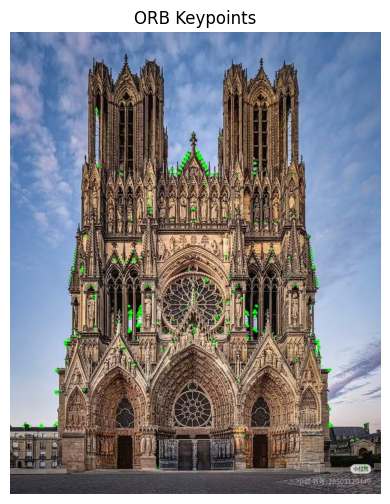

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
path = 'images/architecture.jpg'
print("文件存在吗?", os.path.exists(path))   # True/False
img = cv2.imread(path)
print("读到了吗?", img is not None)           # True 才算读到

img = cv2.imread('images/architecture.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)     # 特征检测在灰度图上做

orb = cv2.ORB_create(nfeatures=500)              # 创建 ORB, 最多找 500 个点
keypoints, descriptors = orb.detectAndCompute(gray, None)  # 检测+算指纹, 一步到位

print("检测到的特征点数量:", len(keypoints))

img_kp = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title('ORB Keypoints')
plt.axis('off')
plt.show()

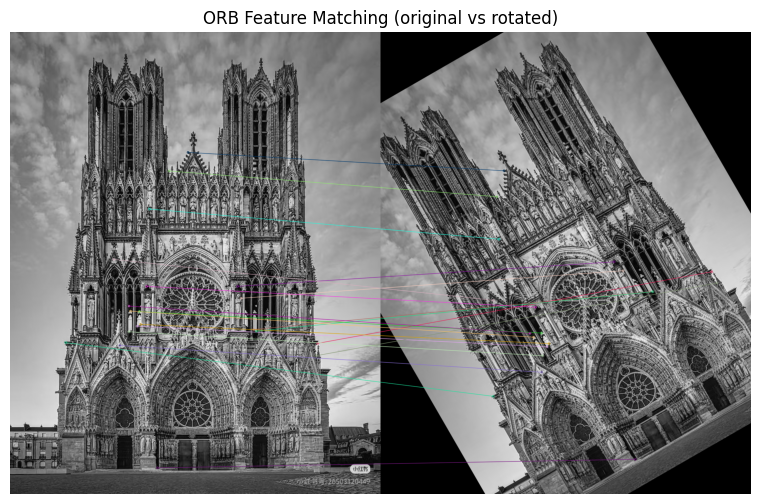

In [5]:
# 造第二张图: 把原图旋转 30 度, 模拟"换角度看同一物体"
h, w = gray.shape
M = cv2.getRotationMatrix2D((w/2, h/2), 30, 1.0)
gray2 = cv2.warpAffine(gray, M, (w, h))

kp1, des1 = orb.detectAndCompute(gray, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)   # 暴力匹配器
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)     # 按匹配质量排序
img_match = cv2.drawMatches(gray, kp1, gray2, kp2, matches[:20], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(14, 6))
plt.imshow(img_match)
plt.title('ORB Feature Matching (original vs rotated)')
plt.axis('off')
plt.show()